In [48]:
from pathlib import Path

import numpy as np
import pandas as pd
from pp5.stats.mht import mht_bh

In [49]:
BASE_PATH = Path("../out/pnas-2026/").resolve()

RESULTS_DIR = BASE_PATH / "results"
assert RESULTS_DIR.is_dir(), f"Results directory {RESULTS_DIR} does not exist"

OUT_DIR = BASE_PATH / "figs"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.absolute()

PosixPath('/Users/avivr/dev/technion/phd/pp5/out/pnas-2026/figs')

## Load analyis results

In [81]:
# Data

LABELLED_TAGS = {
    ### torustest, w2torus metric (no permutation test)
    "w2torus(2-random); none": "pointwise_cdist-t=1-bs=1-k=0-nmax=0-torus_p_nproj=2_randproj=True-cr=none-noself",
    "w2torus(2-random); aa_ss": "pointwise_cdist-t=1-bs=1-k=0-nmax=0-torus_p_nproj=2_randproj=True-cr=aa_ss-noself",
    #
    "w2torus(4-fixed); none": "pointwise_cdist-t=1-bs=1-k=0-nmax=0-torus_p_nproj=4_randproj=False-cr=none-noself",
    "w2torus(4-fixed); aa_ss": "pointwise_cdist-t=1-bs=1-k=0-nmax=0-torus_p_nproj=4_randproj=False-cr=aa_ss-noself",
    #
    ### Permutation test with w2torus metric
    #
    "w2torus-perm(2-random); none": "pointwise_cdist-t=1-bs=1-k=5000-nmax=0-torus_perm_nproj=2_randproj=True-cr=none-noself",
    "w2torus-perm(2-random); aa_ss": "pointwise_cdist-t=1-bs=1-k=5000-nmax=0-torus_perm_nproj=2_randproj=True-cr=aa_ss-noself",
    #
    "w2torus-perm(4-fixed); none": "pointwise_cdist-t=1-bs=1-k=5000-nmax=0-torus_perm_nproj=4_randproj=False-cr=none-noself",
    "w2torus-perm(4-fixed); aa_ss": "pointwise_cdist-t=1-bs=1-k=5000-nmax=0-torus_perm_nproj=4_randproj=False-cr=aa_ss-noself",
    ### Permutation test with KDE-L1 metric
    # #
    "kde-l1(bw=10.0); none": "pointwise_cdist-manual-t_1-bs_1-k_5000-nmax_0-kde_g_10.0-cr_none-noself",
    "kde-l1(bw=10.0); aa_ss": "pointwise_cdist-manual-t_1-bs_1-k_5000-nmax_0-kde_g_10.0-cr_aa_ss-noself",
    # #
    "kde-l1(bw=CV); none": "pointwise_cdist-t=1-bs=1-k=5000-nmax=0-kde_g_bw=cv-cr=none-noself",
    "kde-l1(bw=CV); aa_ss": "pointwise_cdist-t=1-bs=1-k=5000-nmax=0-kde_g_bw=cv-cr=aa_ss-noself",
}

PVALS_FILENAME = "pvals/cc-pvals.csv"

LABELLED_CSV_PATHS = {
    label: Path(RESULTS_DIR) / tag / PVALS_FILENAME
    for label, tag in LABELLED_TAGS.items()
}

In [82]:
for _, _csv_path in LABELLED_CSV_PATHS.items():
    assert _csv_path.is_file(), str(_csv_path)

In [83]:
_csv_path = next(iter(LABELLED_CSV_PATHS.values()))
_df = pd.read_csv(_csv_path)
_df.head()

,condition_group,subgroup1,subgroup2,n1,n2,phi1_mean,psi1_mean,phi2_mean,psi2_mean,d12,pval,ddist,significant
0,HELIX,L-CTC,L-CTG,528,2812,-66.176835,-37.717240,-65.223519,-39.349970,1.890666,0.000,0.452742,True
1,HELIX,L-CTC,L-TTG,528,599,-66.176835,-37.717240,-65.148195,-39.742460,2.271478,0.000,0.369836,True
2,HELIX,P-CCC,P-CCT,92,151,-59.370040,-35.431395,-58.398541,-36.500818,1.444810,0.026,0.193612,False
3,HELIX,G-GGA,G-GGT,153,462,-63.320628,-39.383827,-60.929911,-42.138466,3.647405,0.031,0.218664,False
4,HELIX,Q-CAA,Q-CAG,828,1629,-65.262840,-38.494280,-65.033755,-38.954806,0.514357,0.031,0.207236,False


In [84]:
def _get_stat_test_type(k: str) -> str:
    return k.split(";")[0].strip()


def _get_randomization_type(k: str) -> str:
    return k.split(";")[1].strip()


### Load all pval csvs into single df

In [85]:
pval_dfs = []

for run_label, csv_path in LABELLED_CSV_PATHS.items():
    df = pd.read_csv(csv_path).copy()

    stat_test_name = _get_stat_test_type(run_label)
    randomization_type = _get_randomization_type(run_label)

    df["stat_test"] = stat_test_name
    df["codon_randomization"] = randomization_type
    pval_dfs.append(df)

In [86]:
df_all_pvals = pd.concat(pval_dfs, axis=0)
df_all_pvals.to_csv(OUT_DIR / "pvals.csv", index=False)
df_all_pvals

,condition_group,subgroup1,subgroup2,n1,n2,phi1_mean,psi1_mean,phi2_mean,psi2_mean,d12,pval,ddist,significant,stat_test,codon_randomization
0,HELIX,L-CTC,L-CTG,528,2812,-66.176835,-37.717240,-65.223519,-39.349970,1.890666,0.000000,0.452742,True,w2torus(2-random),none
1,HELIX,L-CTC,L-TTG,528,599,-66.176835,-37.717240,-65.148195,-39.742460,2.271478,0.000000,0.369836,True,w2torus(2-random),none
2,HELIX,P-CCC,P-CCT,92,151,-59.370040,-35.431395,-58.398541,-36.500818,1.444810,0.026000,0.193612,False,w2torus(2-random),none
3,HELIX,G-GGA,G-GGT,153,462,-63.320628,-39.383827,-60.929911,-42.138466,3.647405,0.031000,0.218664,False,w2torus(2-random),none
4,HELIX,Q-CAA,Q-CAG,828,1629,-65.262840,-38.494280,-65.033755,-38.954806,0.514357,0.031000,0.207236,False,w2torus(2-random),none
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,TURN,S-TCA,S-TCC,156,224,-73.889062,-9.825850,-72.864800,-6.070989,3.892056,0.980392,0.411151,False,kde-l1(bw=CV),aa_ss
344,TURN,R-AGA,R-CGA,37,88,-70.794883,8.325403,-66.554292,1.724830,7.845392,0.990099,0.468606,False,kde-l1(bw=CV),aa_ss
345,TURN,G-GGC,G-GGT,1606,1319,80.869529,1.705079,79.732616,2.330890,1.297771,0.990099,0.110475,False,kde-l1(bw=CV),aa_ss
346,TURN,S-AGC,S-AGT,388,224,-73.538577,-6.302294,-72.289923,-5.694079,1.388907,1.000000,0.113379,False,kde-l1(bw=CV),aa_ss


In [87]:
stat_test_names = sorted(df_all_pvals["stat_test"].unique())
randomization_names = sorted(df_all_pvals["codon_randomization"].unique())

stat_test_names, randomization_names

(['kde-l1(bw=10.0)',
  'kde-l1(bw=CV)',
  'w2torus(2-random)',
  'w2torus(4-fixed)',
  'w2torus-perm(2-random)',
  'w2torus-perm(4-fixed)'],
 ['aa_ss', 'none'])

## Plot pval CDFs per SS type

And compute number of rejections across all AAs in each SS.

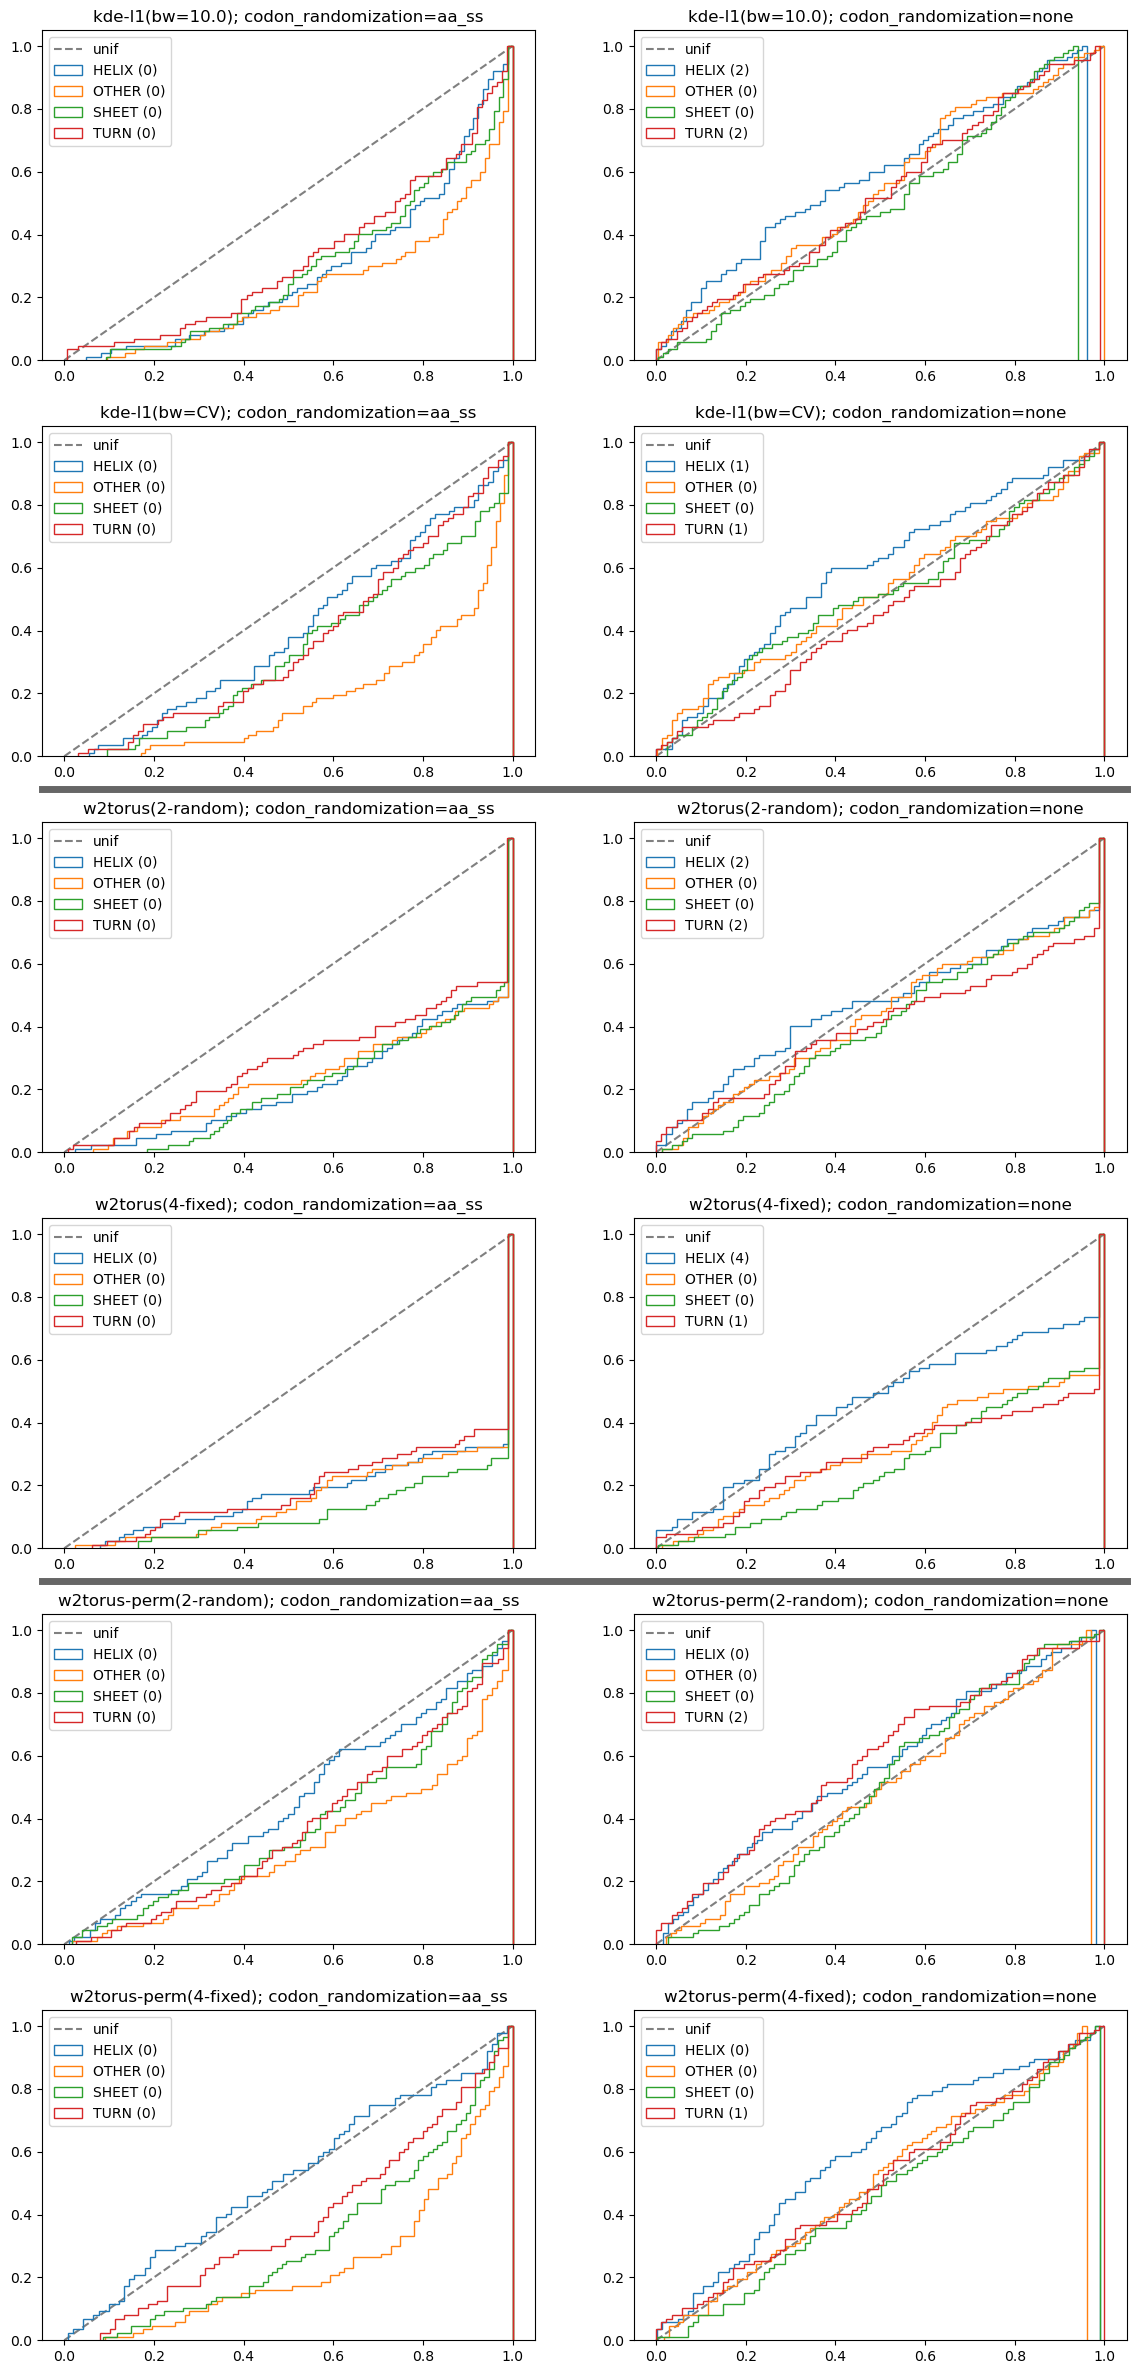

In [98]:
from itertools import product

import matplotlib.pyplot as plt

FDR = 0.1 / 2

rejections_df_entries = []

nrows, ncols = len(stat_test_names), len(randomization_names)
fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=(7 * ncols, 5 * nrows), squeeze=False
)

for stat_test_name, randomization_type in product(stat_test_names, randomization_names):
    idx = (df_all_pvals["stat_test"] == stat_test_name) & (
        df_all_pvals["codon_randomization"] == randomization_type
    )
    df = df_all_pvals[idx]
    assert len(df)

    ax = axes[
        stat_test_names.index(stat_test_name),
        randomization_names.index(randomization_type),
    ]
    ax.set_title(f"{stat_test_name}; codon_randomization={randomization_type}")
    ax.plot([0.0, 1.0], [0.0, 1.0], ls="--", color="gray", label="unif")

    for ss, df_group in df.groupby(by="condition_group"):
        pvals = df_group["pval"].to_numpy()
        m = len(pvals)
        if m == 0:
            continue

        # Benjamini-Hochberg procedure
        p_thresh = mht_bh(q=FDR, pvals=pvals)
        pv_lt_thresh = pvals <= p_thresh
        n_rejected = np.sum(pv_lt_thresh)

        df_group_rejected = df_group[pv_lt_thresh]
        assert len(df_group_rejected) == n_rejected
        rejected_pairs = [
            f"{c1}:{c2}"
            for c1, c2 in zip(
                df_group_rejected["subgroup1"], df_group_rejected["subgroup2"]
            )
        ]
        rejected_pairs_str = str.join("; ", rejected_pairs)

        rejections_df_entries.append(
            {
                "stat_test": stat_test_name,
                "codon_randomization": randomization_type,
                "SS": ss,
                "n_hypotheses": m,
                "FDR": FDR,
                "bh_pvalue_threshold": p_thresh,
                "n_rejected": n_rejected,
                "rejected_pairs": rejected_pairs_str,
            }
        )

        ax.hist(
            pvals,
            bins=len(pvals),
            density=True,
            cumulative=True,
            label=f"{ss} ({n_rejected})",
            histtype="step",
        )
        ax.grid()
        ax.legend()

from matplotlib.lines import Line2D

fig.canvas.draw()

left = axes[0, 0].get_position().x0
right = axes[0, -1].get_position().x1

for row_break in range(2, nrows, 2):
    upper_row = axes[row_break - 1, 0].get_position()
    lower_row = axes[row_break, 0].get_position()
    y = 0.5 * (upper_row.y0 + lower_row.y1)

    fig.add_artist(
        Line2D(
            [left, right],
            [y, y],
            transform=fig.transFigure,
            color="black",
            lw=5.0,
            alpha=0.6,
        )
    )

In [99]:
fig.savefig(OUT_DIR / "pvals-cdf.pdf", bbox_inches="tight")

In [100]:
# Compile rejections into a DataFrame
df_rejections = pd.DataFrame(rejections_df_entries)
df_rejections.to_csv(OUT_DIR / "rejections.csv", index=False)
df_rejections

,stat_test,codon_randomization,SS,n_hypotheses,FDR,bh_pvalue_threshold,n_rejected,rejected_pairs
0,kde-l1(bw=10.0),aa_ss,HELIX,87,0.05,0.000000,0,
1,kde-l1(bw=10.0),aa_ss,OTHER,87,0.05,0.000000,0,
2,kde-l1(bw=10.0),aa_ss,SHEET,87,0.05,0.000000,0,
3,kde-l1(bw=10.0),aa_ss,TURN,87,0.05,0.000000,0,
4,kde-l1(bw=10.0),none,HELIX,87,0.05,0.001149,2,L-CTC:L-TTG; L-CTC:L-CTG
5,kde-l1(bw=10.0),none,OTHER,87,0.05,0.000000,0,
6,kde-l1(bw=10.0),none,SHEET,87,0.05,0.000000,0,
7,kde-l1(bw=10.0),none,TURN,87,0.05,0.001149,2,P-CCC:P-CCG; A-GCG:A-GCT
8,kde-l1(bw=CV),aa_ss,HELIX,87,0.05,0.000000,0,
9,kde-l1(bw=CV),aa_ss,OTHER,87,0.05,0.000000,0,


## Repeat BH-q test but only within the same AA

In [101]:
aa1_col, aa2_col = [df_all_pvals[f"subgroup{j}"].str.get(0) for j in ("1", "2")]

# Sanity: all tests are comparing codons from the same AA
assert np.all(aa1_col == aa2_col)

In [102]:
print(f"{len(aa1_col.unique())=}")
print(sorted(aa1_col.unique()))

len(aa1_col.unique())=18
['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'Y']


In [103]:
rejections_aa_df_entries = []

for (ss, aa, stat_test_name, randomization_type), df_group in df_all_pvals.groupby(
    by=["condition_group", aa1_col, "stat_test", "codon_randomization"]
):
    pvals = df_group["pval"].to_numpy()
    m = len(pvals)
    if m < 1:
        raise RuntimeError("Empty?")

    # Benjamini-Hochberg procedure if m > 1
    if m > 1:
        p_thresh = mht_bh(q=FDR, pvals=pvals)
    else:
        p_thresh = FDR  # regular pval significance check

    pv_lt_thresh = pvals <= p_thresh
    n_rejected = np.sum(pv_lt_thresh)

    df_group_rejected = df_group[pv_lt_thresh]
    assert len(df_group_rejected) == n_rejected
    rejected_pairs = [
        f"{c1}:{c2}"
        for c1, c2 in zip(
            df_group_rejected["subgroup1"], df_group_rejected["subgroup2"]
        )
    ]
    rejected_pairs_str = str.join("; ", rejected_pairs)

    rejections_aa_df_entries.append(
        {
            "stat_test": stat_test_name,
            "codon_randomization": randomization_type,
            "SS": ss,
            "AA": aa,
            "n_hypotheses": m,
            "FDR": FDR,
            "bh_pvalue_threshold": p_thresh,
            "n_rejected": n_rejected,
            "rejected_pairs": rejected_pairs_str,
        }
    )

    # print(
    #     f"{ss=}, {aa=}, {stat_test_name=}, {randomization_type=}, {m=}, {n_rejected=}"
    # )

In [104]:
df_rejections_aa = pd.DataFrame(rejections_aa_df_entries)
df_rejections_aa = df_rejections_aa.sort_values(
    by=["stat_test", "codon_randomization", "SS", "AA", "n_hypotheses"]
)

df_rejections_aa.to_csv(OUT_DIR / "rejections_aa.csv", index=False)
df_rejections_aa

,stat_test,codon_randomization,SS,AA,n_hypotheses,FDR,bh_pvalue_threshold,n_rejected,rejected_pairs
0,kde-l1(bw=10.0),aa_ss,HELIX,A,6,0.05,0.00,0,
12,kde-l1(bw=10.0),aa_ss,HELIX,C,1,0.05,0.05,0,
24,kde-l1(bw=10.0),aa_ss,HELIX,D,1,0.05,0.05,0,
36,kde-l1(bw=10.0),aa_ss,HELIX,E,1,0.05,0.05,0,
48,kde-l1(bw=10.0),aa_ss,HELIX,F,1,0.05,0.05,0,
...,...,...,...,...,...,...,...,...,...
815,w2torus-perm(4-fixed),none,TURN,R,15,0.05,0.00,0,
827,w2torus-perm(4-fixed),none,TURN,S,15,0.05,0.00,0,
839,w2torus-perm(4-fixed),none,TURN,T,6,0.05,0.00,0,
851,w2torus-perm(4-fixed),none,TURN,V,6,0.05,0.00,0,


In [105]:
# Check for any rejections in the control data
idx_rejected_null = (df_rejections_aa["codon_randomization"] == "aa_ss") & (
    df_rejections_aa["n_rejected"] > 0
)
df_rejections_aa[idx_rejected_null]

,stat_test,codon_randomization,SS,AA,n_hypotheses,FDR,bh_pvalue_threshold,n_rejected,rejected_pairs
832,w2torus(2-random),aa_ss,TURN,T,6,0.05,0.008333,1,T-ACA:T-ACT
680,w2torus-perm(2-random),aa_ss,TURN,D,1,0.05,0.050000,1,D-GAC:D-GAT
202,w2torus-perm(4-fixed),aa_ss,HELIX,V,6,0.05,0.008333,1,V-GTA:V-GTC


In [106]:
# Total number of hypotheses per SS should be 87
df_rejections_aa.groupby(by=["stat_test", "codon_randomization", "SS"])[
    "n_hypotheses"
].sum()

stat_test               codon_randomization  SS   
kde-l1(bw=10.0)         aa_ss                HELIX    87
                                             OTHER    87
                                             SHEET    87
                                             TURN     87
                        none                 HELIX    87
                                             OTHER    87
                                             SHEET    87
                                             TURN     87
kde-l1(bw=CV)           aa_ss                HELIX    87
                                             OTHER    87
                                             SHEET    87
                                             TURN     87
                        none                 HELIX    87
                                             OTHER    87
                                             SHEET    87
                                             TURN     87
w2torus(2-random)       aa_ss        

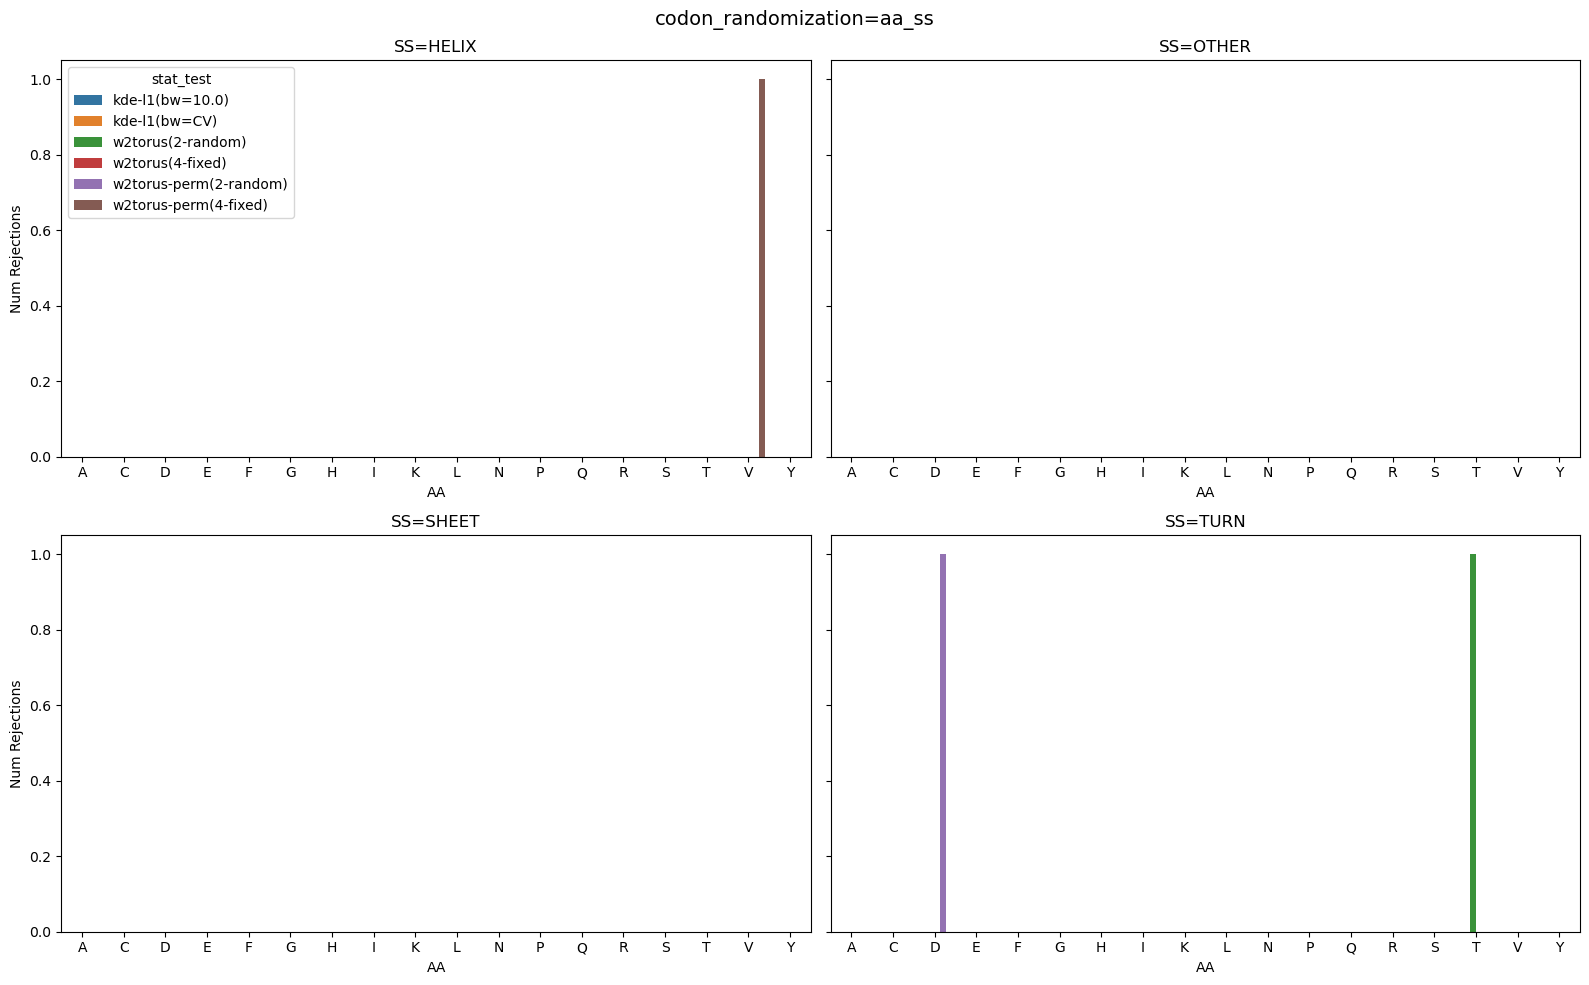

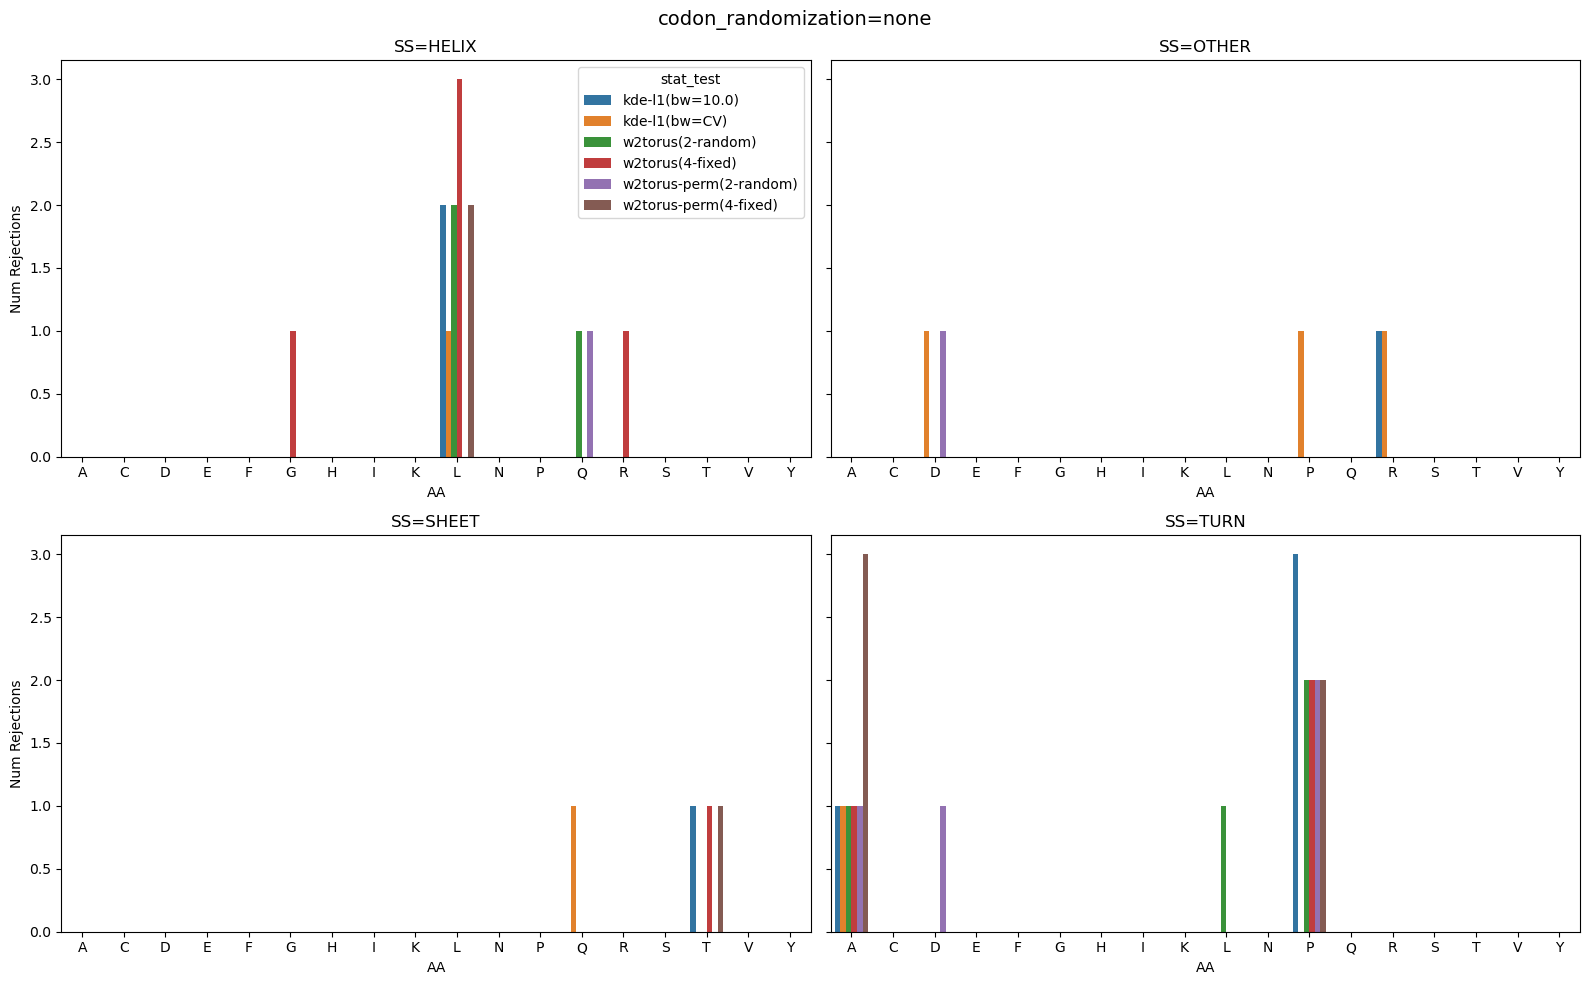

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

df = df_rejections_aa.copy()

ALL_AAS = sorted(df["AA"].dropna().unique().tolist())
ALL_SS = sorted(df["SS"].dropna().unique().tolist())
ALL_RAND_TYPES = sorted(df["codon_randomization"].unique().tolist())

assert len(ALL_SS) == 4
assert len(ALL_AAS) == 18  # M and W only have a single codon

# One figure per codon_randomization value, split into four subplots for the AAs
for randomization_type in ALL_RAND_TYPES:
    d = df[df["codon_randomization"] == randomization_type].copy()
    stat_tests = sorted(d["stat_test"].dropna().unique().tolist())

    fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
    axes = axes.flatten()
    for i, ss in enumerate(ALL_SS):
        ax = axes[i]
        sub = d[d["SS"] == ss]
        sns.barplot(
            data=sub,
            x="AA",
            y="n_rejected",
            hue="stat_test",
            order=ALL_AAS,
            hue_order=stat_tests,
            errorbar=None,
            ax=ax,
        )
        ax.set_title(f"SS={ss}")
        ax.set_xlabel("AA")
        ax.set_ylabel("Num Rejections")
        ax.tick_params(axis="x", rotation=0)
        # legend only on the first subplot
        if i != 0:
            ax.get_legend().remove()
    fig.suptitle(f"codon_randomization={randomization_type}", fontsize=14)
    plt.tight_layout()
    fig.savefig(OUT_DIR / f"rejections_aa-codon_randomization={randomization_type}.pdf")